<a href="https://colab.research.google.com/github/HikariJadeEmpire/TH_WLRD_Happiness_Project/blob/main/WH_CodeSpace.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# STEP 1
- import & Clean DATA
- learning about the data

In [1]:
import sys
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

print( f"Python {sys.version}\nPandas {pd.__version__}\nNumPy {np.__version__}\nMatplotlib {mpl.__version__}\n" ) 

Python 3.9.12 (main, Apr  4 2022, 05:22:27) [MSC v.1916 64 bit (AMD64)]
Pandas 1.4.2
NumPy 1.21.5
Matplotlib 3.5.1



In [2]:
df_w = pd.read_csv('https://raw.githubusercontent.com/HikariJadeEmpire/TH_WLRD_Happiness_Project/main/DataForTable2')  
df_w_overall = pd.read_csv('https://raw.githubusercontent.com/HikariJadeEmpire/TH_WLRD_Happiness_Project/main/Appendix_2_Data_for_Figure_2')

df_w.info() # we will use this to be the main file
#df_w_overall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country name                       2089 non-null   object 
 1   year                               2089 non-null   int64  
 2   Life Ladder                        2089 non-null   float64
 3   Log GDP per capita                 2062 non-null   float64
 4   Social support                     2076 non-null   float64
 5   Healthy life expectancy at birth   2031 non-null   float64
 6   Freedom to make life choices       2057 non-null   float64
 7   Generosity                         2009 non-null   float64
 8   Perceptions of corruption          1976 non-null   float64
 9   Positive affect                    2065 non-null   float64
 10  Negative affect                    2073 non-null   float64
 11  Confidence in national government  1873 non-null   float

In [3]:
# Clean Column name to avoid error (eg.remove 'space')

df = df_w.rename(columns={'Country name':'country_name',
'Life Ladder':'life_lad','Log GDP per capita':'gdp_per_cap',
'Social support':'social_sup','Healthy life expectancy at birth':'health',
'Freedom to make life choices':'life_choice','Generosity':'generosity',
'Perceptions of corruption':'corruption','Positive affect':'pos_aff','Negative affect':'neg_aff',
'Confidence in national government':'conf_in_gov'} )

df['year'] = df['year'].agg(lambda x : str(x))

# get results
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  2089 non-null   object 
 1   year          2089 non-null   object 
 2   life_lad      2089 non-null   float64
 3   gdp_per_cap   2062 non-null   float64
 4   social_sup    2076 non-null   float64
 5   health        2031 non-null   float64
 6   life_choice   2057 non-null   float64
 7   generosity    2009 non-null   float64
 8   corruption    1976 non-null   float64
 9   pos_aff       2065 non-null   float64
 10  neg_aff       2073 non-null   float64
 11  conf_in_gov   1873 non-null   float64
dtypes: float64(10), object(2)
memory usage: 196.0+ KB


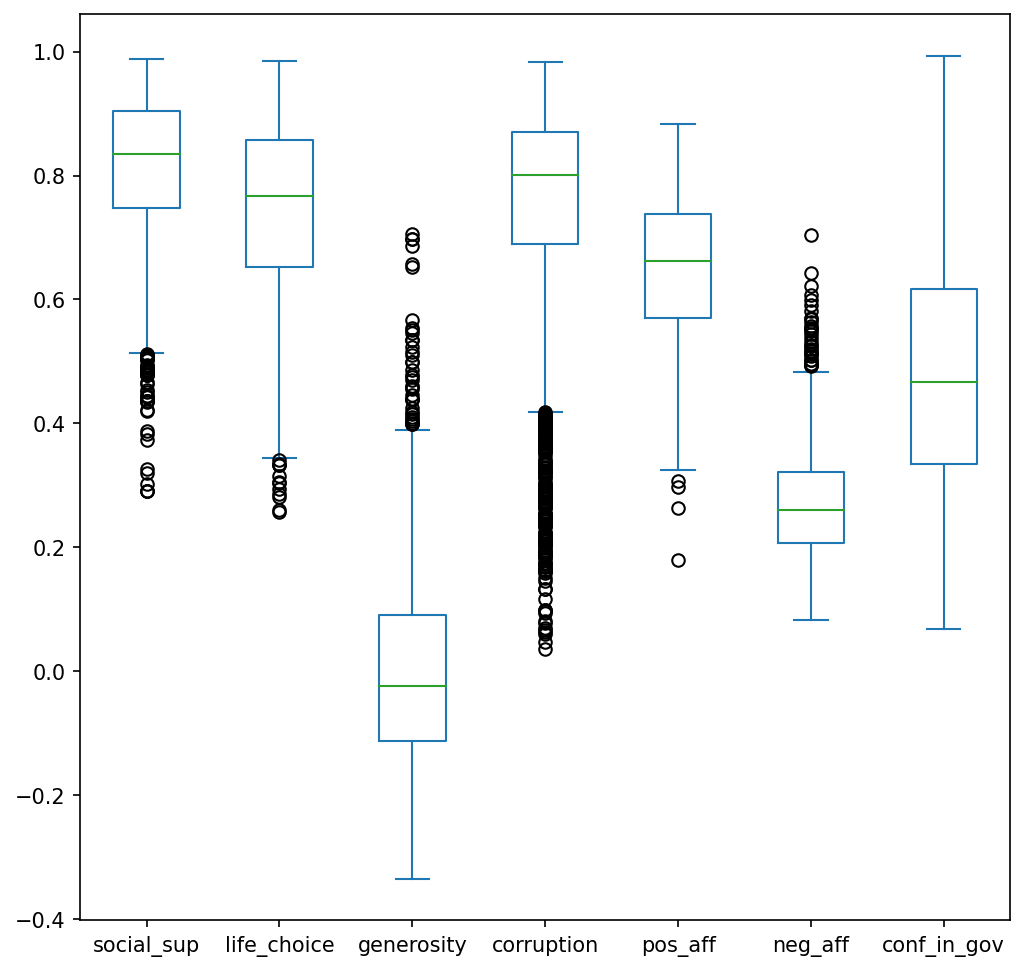

In [4]:
# Check Outliers on each column before grouping

df_ol_1 = df.loc[ :,[ 'social_sup','life_choice','generosity','corruption','pos_aff','neg_aff','conf_in_gov' ] ]
df_ol_2 = df.loc[ :,[ 'health' ] ]
df_ol_3 = df.loc[ :,[ 'life_lad','gdp_per_cap' ] ]

plt.style.use('fast')
plt.figure( figsize=(8, 8), dpi=150 )
ax = plt.gca()

# Plot
_1 = df_ol_1.plot(kind='box', ax=ax)

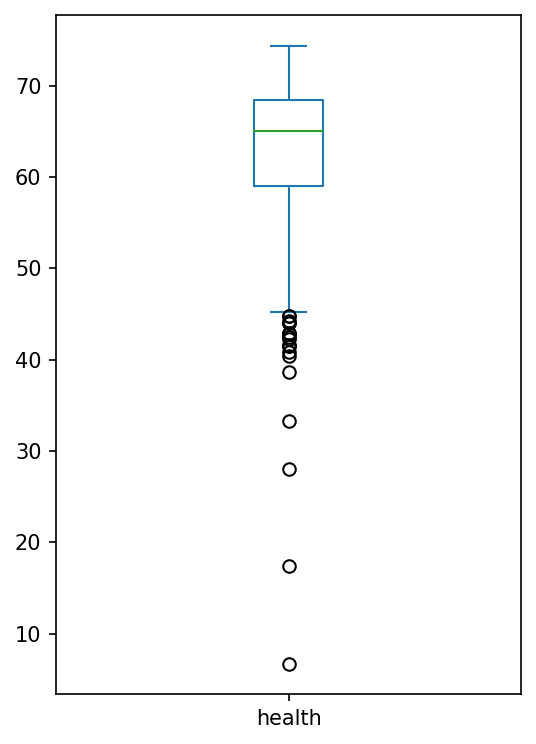

In [5]:
plt.figure( figsize=(4, 6), dpi=150 )
ax = plt.gca()
_2 = df_ol_2.plot(kind='box', ax=ax)

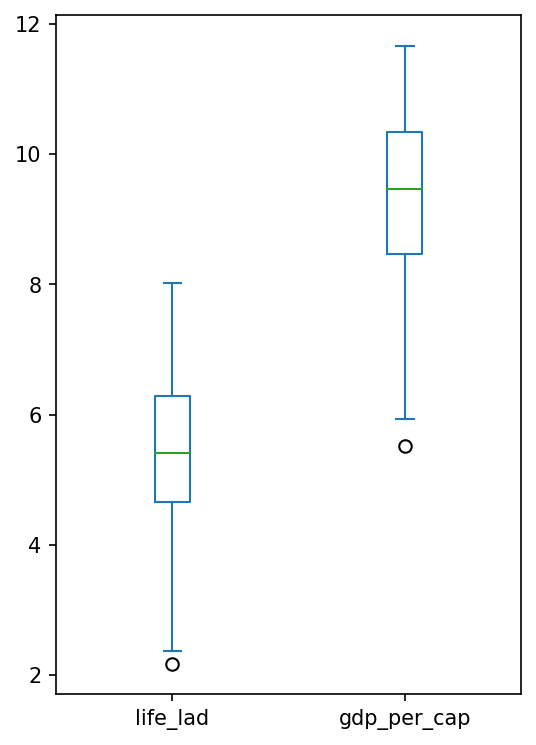

In [6]:
plt.figure( figsize=(4, 6), dpi=150 )
ax = plt.gca()
_3 = df_ol_3.plot(kind='box', ax=ax)

In [7]:
df_ol_b = df

# drop outliers

Q1 = df_ol_b.iloc[:,2:].quantile(0.25)
Q3 = df_ol_b.iloc[:,2:].quantile(0.75)
IQR = Q3 - Q1

df_ol = df_ol_b.loc[ :,['country_name','year'] ]
for i,j in enumerate(df_ol_b):
    if i > 1 :
        min_outlier = (Q1[j] - 1.5 * IQR[j]) ; max_outlier = (Q3[j] + 1.5 * IQR[j])

        df_ol_0 = df_ol_b.loc[ (df_ol_b[j] >= min_outlier)|(df_ol_b[j] <= max_outlier) ,['country_name','year',j]  ]
        df_ol = pd.merge(df_ol,df_ol_0,left_on=['country_name','year'],right_on=['country_name','year'],how='left')

print( f" {'-'*6} here is the DATA that clears out outliers {'-'*6} " )
display(df_ol)

 ------ here is the DATA that clears out outliers ------ 


,country_name,year,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Afghanistan,2008,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,0.258195,0.612072
1,Afghanistan,2009,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,0.237092,0.611545
2,Afghanistan,2010,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,0.275324,0.299357
3,Afghanistan,2011,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,0.267175,0.307386
4,Afghanistan,2012,3.782938,7.637953,0.520637,51.700001,0.530935,0.241247,0.775620,0.613513,0.267919,0.435440
...,...,...,...,...,...,...,...,...,...,...,...,...
2084,Zimbabwe,2017,3.638300,8.241609,0.754147,52.150002,0.752826,-0.113937,0.751208,0.733641,0.224051,0.682647
2085,Zimbabwe,2018,3.616480,8.274620,0.775388,52.625000,0.762675,-0.084747,0.844209,0.657524,0.211726,0.550508
2086,Zimbabwe,2019,2.693523,8.196998,0.759162,53.099998,0.631908,-0.081540,0.830652,0.658434,0.235354,0.456455
2087,Zimbabwe,2020,3.159802,8.117733,0.717243,53.575001,0.643303,-0.029376,0.788523,0.660658,0.345736,0.577302


In [8]:
# Replace NaN by median respect to country

for i,name in enumerate(list(df)):
    if i > 2 :
        df[name].fillna(df_ol.groupby(['country_name'])[name].transform('median'),inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  2089 non-null   object 
 1   year          2089 non-null   object 
 2   life_lad      2089 non-null   float64
 3   gdp_per_cap   2073 non-null   float64
 4   social_sup    2088 non-null   float64
 5   health        2051 non-null   float64
 6   life_choice   2089 non-null   float64
 7   generosity    2073 non-null   float64
 8   corruption    2060 non-null   float64
 9   pos_aff       2087 non-null   float64
 10  neg_aff       2088 non-null   float64
 11  conf_in_gov   1992 non-null   float64
dtypes: float64(10), object(2)
memory usage: 196.0+ KB


Look like some of them are still NaN.<br>
We've got to see what happened.

In [9]:
see=df.loc[ df['gdp_per_cap'].isna() | df['social_sup'].isna() | df['health'].isna() | df['generosity'].isna() 
           | df['corruption'].isna() | df['conf_in_gov'].isna() | df['neg_aff'].isna() , : ].groupby(by=['country_name'])

print(f"\n {'-'*4} List of countries that have NaN {'-'*4} \n")
for i in (see.groups) :
    print(i)

print(f"\n {'-'*4} For example {'-'*4} \n")

see1 = df.loc[df['country_name'].isin(['China']) ,:].reset_index(drop=True)
see2 = df.loc[df['country_name'].isin(['Hong Kong S.A.R. of China']) ,:].reset_index(drop=True)

display(see1)
display(see2)


 ---- List of countries that have NaN ---- 

Algeria
Bahrain
China
Cuba
Hong Kong S.A.R. of China
Kosovo
Libya
Maldives
North Cyprus
Oman
Saudi Arabia
Somaliland region
South Sudan
Sudan
Syria
Turkmenistan
United Arab Emirates

 ---- For example ---- 



,country_name,year,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,China,2006,4.560495,8.696139,0.747011,65.660004,0.853072,-0.173937,NaN,0.657659,0.169580,NaN
1,China,2007,4.862862,8.823968,0.810852,65.919998,0.853072,-0.176961,NaN,0.663977,0.158614,NaN
2,China,2008,4.846295,8.910974,0.748287,66.180000,0.853072,-0.093270,NaN,0.705133,0.146963,NaN
3,China,2009,4.454361,8.995829,0.798034,66.440002,0.771143,-0.161358,NaN,0.669666,0.161650,NaN
4,China,2010,4.652737,9.092073,0.767753,66.699997,0.804794,-0.134285,NaN,0.658101,0.158100,NaN
5,China,2011,5.037208,9.177827,0.787171,66.959999,0.824162,-0.187382,NaN,0.710055,0.133503,NaN
6,China,2012,5.094917,9.246742,0.787818,67.220001,0.808255,-0.185606,NaN,0.689160,0.158703,NaN
7,China,2013,5.241090,9.314875,0.777896,67.480003,0.804724,-0.158647,NaN,0.717136,0.142211,NaN
8,China,2014,5.195619,9.380201,0.820366,67.739998,0.853072,-0.217615,NaN,0.709763,0.111518,NaN
9,China,2015,5.303878,9.442431,0.793734,68.000000,0.853072,-0.245284,NaN,0.666827,0.171315,NaN


,country_name,year,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Hong Kong S.A.R. of China,2006,5.511187,10.746424,0.812178,NaN,0.909820,0.153046,0.355985,0.591140,0.235955,0.663938
1,Hong Kong S.A.R. of China,2008,5.137262,10.815546,0.840222,NaN,0.922211,0.293682,0.273945,0.575073,0.236634,0.677437
2,Hong Kong S.A.R. of China,2009,5.397056,10.788493,0.834716,NaN,0.918026,0.305077,0.272125,0.606459,0.210104,0.619142
3,Hong Kong S.A.R. of China,2010,5.642835,10.846634,0.857314,NaN,0.890418,0.329340,0.255775,0.600561,0.183106,0.634737
4,Hong Kong S.A.R. of China,2011,5.474011,10.886932,0.846060,NaN,0.894330,0.231902,0.244887,0.582491,0.195712,0.584562
5,Hong Kong S.A.R. of China,2012,5.483765,10.892753,0.826426,NaN,0.879752,0.219744,0.379783,0.580223,0.183349,0.497906
6,Hong Kong S.A.R. of China,2014,5.458051,10.939503,0.833558,NaN,0.843082,0.221097,0.422960,0.602495,0.242868,0.457823
7,Hong Kong S.A.R. of China,2016,5.498421,10.969857,0.832078,NaN,0.799743,0.097504,0.402813,0.568555,0.213115,0.449610
8,Hong Kong S.A.R. of China,2017,5.362475,10.999584,0.831066,NaN,0.830657,0.137305,0.415810,0.535812,0.200593,0.545041
9,Hong Kong S.A.R. of China,2019,5.659317,10.995179,0.855826,NaN,0.726852,0.064956,0.431974,0.519312,0.357607,0.332540


Here is the list of countries that still have NaN.<br> 
They have it because they hadn't had any records before<br>
so we can't calculate median from NaN and fill them<br>
- We will consider dropping a country that is not in our interest and keeping the interesting one.<br>
- Else, we just have to keep them.

By the way, these countries still can be helpful in other steps so we decided to keep them <br>
Now, It's time to learn the features of DATA<br>

In [10]:
# Prepare data, sort by the best mean of life_lad ( drop outlier )

winner_df_ol = df_ol.groupby('country_name').apply(lambda x : x[['life_lad','gdp_per_cap','social_sup',
    'health','life_choice','generosity','corruption','pos_aff',
    'neg_aff','conf_in_gov']].mean()).sort_values(by=['life_lad'],ascending=False).reset_index()

# Prepare data, sort by the best mean of life_lad ( keep outlier )

winner_df = df.groupby(['country_name']).apply(lambda x : x[['life_lad','gdp_per_cap','social_sup',
    'health','life_choice','generosity','corruption','pos_aff',
    'neg_aff','conf_in_gov']].mean()).sort_values(by=['life_lad'],ascending=False).reset_index()

print( f" {'-'*6} here is the DATA that have outliers {'-'*6} " )
display(winner_df)


 ------ here is the DATA that have outliers ------ 


,country_name,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Denmark,7.681457,10.885137,0.956441,70.031562,0.944400,0.165070,0.198672,0.783656,0.197597,0.578037
1,Finland,7.611299,10.753935,0.950494,70.325358,0.941380,-0.001996,0.244848,0.738809,0.185581,0.596645
2,Switzerland,7.528177,11.127461,0.942772,71.978181,0.923328,0.094757,0.304179,0.756787,0.189489,0.770718
3,Norway,7.498840,11.059574,0.950138,70.931818,0.952737,0.135409,0.336738,0.786417,0.201050,0.675312
4,Iceland,7.459697,10.878041,0.977832,71.816666,0.930586,0.255945,0.696809,0.810800,0.162326,0.428385
...,...,...,...,...,...,...,...,...,...,...,...
161,Togo,3.603208,7.538181,0.470834,54.076000,0.622879,-0.041133,0.799416,0.564185,0.419719,0.424578
162,Burundi,3.548124,6.722510,0.417652,52.008000,0.451014,-0.035402,0.732270,0.570199,0.244124,0.736995
163,Central African Republic,3.514954,6.960999,0.402559,43.374000,0.680430,0.027961,0.842129,0.539942,0.391497,0.711735
164,Afghanistan,3.505506,7.586585,0.504086,52.353846,0.508496,0.077007,0.851207,0.450821,0.348225,0.382015


To define what the Happiest countries look like, we join the 'happiness score' column from 'df_w_overall' file <br>
then sort the first 10th countries and define what the Happiest country looks like

 
------ BEFORE Feature scaling ------
 


,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Finland,7.821,7.611299,10.753935,0.950494,70.325358,0.941380,-0.001996,0.244848,0.738809,0.185581,0.596645
1,Denmark,7.636,7.681457,10.885137,0.956441,70.031562,0.944400,0.165070,0.198672,0.783656,0.197597,0.578037
2,Iceland,7.557,7.459697,10.878041,0.977832,71.816666,0.930586,0.255945,0.696809,0.810800,0.162326,0.428385
3,Switzerland,7.512,7.528177,11.127461,0.942772,71.978181,0.923328,0.094757,0.304179,0.756787,0.189489,0.770718
4,Netherlands,7.415,7.456150,10.886151,0.932535,71.098333,0.904099,0.274062,0.413667,0.733098,0.212143,0.603382
...,...,...,...,...,...,...,...,...,...,...,...,...
142,Rwanda*,3.268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,Zimbabwe,2.995,3.837182,8.086318,0.792329,48.448437,0.592836,-0.100058,0.838707,0.651847,0.225499,0.476866
144,Lebanon,2.955,4.659638,9.665533,0.739500,65.622187,0.607290,-0.010961,0.907849,0.451795,0.351312,0.222726
145,Afghanistan,2.404,3.505506,7.586585,0.504086,52.353846,0.508496,0.077007,0.851207,0.450821,0.348225,0.382015


 
------ AFTER Feature scaling by Min - Max scaler ------
 


,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
0,Finland,1.000000,0.983199,0.865617,0.946079,0.878084,0.974436,0.305999,0.169563,0.781204,0.175777,0.539758
1,Denmark,0.965848,1.000000,0.896020,0.957809,0.866506,0.981233,0.493762,0.115118,0.899958,0.206261,0.515699
2,Iceland,0.951265,0.946896,0.894376,1.000000,0.936853,0.950138,0.595895,0.702459,0.971835,0.116785,0.322206
3,Switzerland,0.942957,0.963295,0.952174,0.930848,0.943218,0.933800,0.414738,0.239519,0.828809,0.185692,0.764826
4,Netherlands,0.925051,0.946046,0.896255,0.910657,0.908545,0.890515,0.616257,0.368614,0.766083,0.243160,0.548468
5,Sweden,0.919328,0.926347,0.878675,0.901891,0.922367,0.951188,0.474881,0.184763,0.843597,0.164301,0.493890
6,Norway,0.915821,0.956269,0.936442,0.945377,0.901983,1.000000,0.460426,0.277909,0.907269,0.215020,0.641471
7,Israel,0.915636,0.894491,0.806509,0.854887,0.935088,0.497147,0.436952,0.860185,0.455363,0.474504,0.260138
8,New Zealand,0.885361,0.908350,0.831434,0.950376,0.863410,0.931413,0.589850,0.193596,0.903753,0.212975,0.554500
9,Austria,0.878531,0.892038,0.895357,0.895482,0.879689,0.877332,0.454991,0.547322,0.720683,0.171846,0.360313


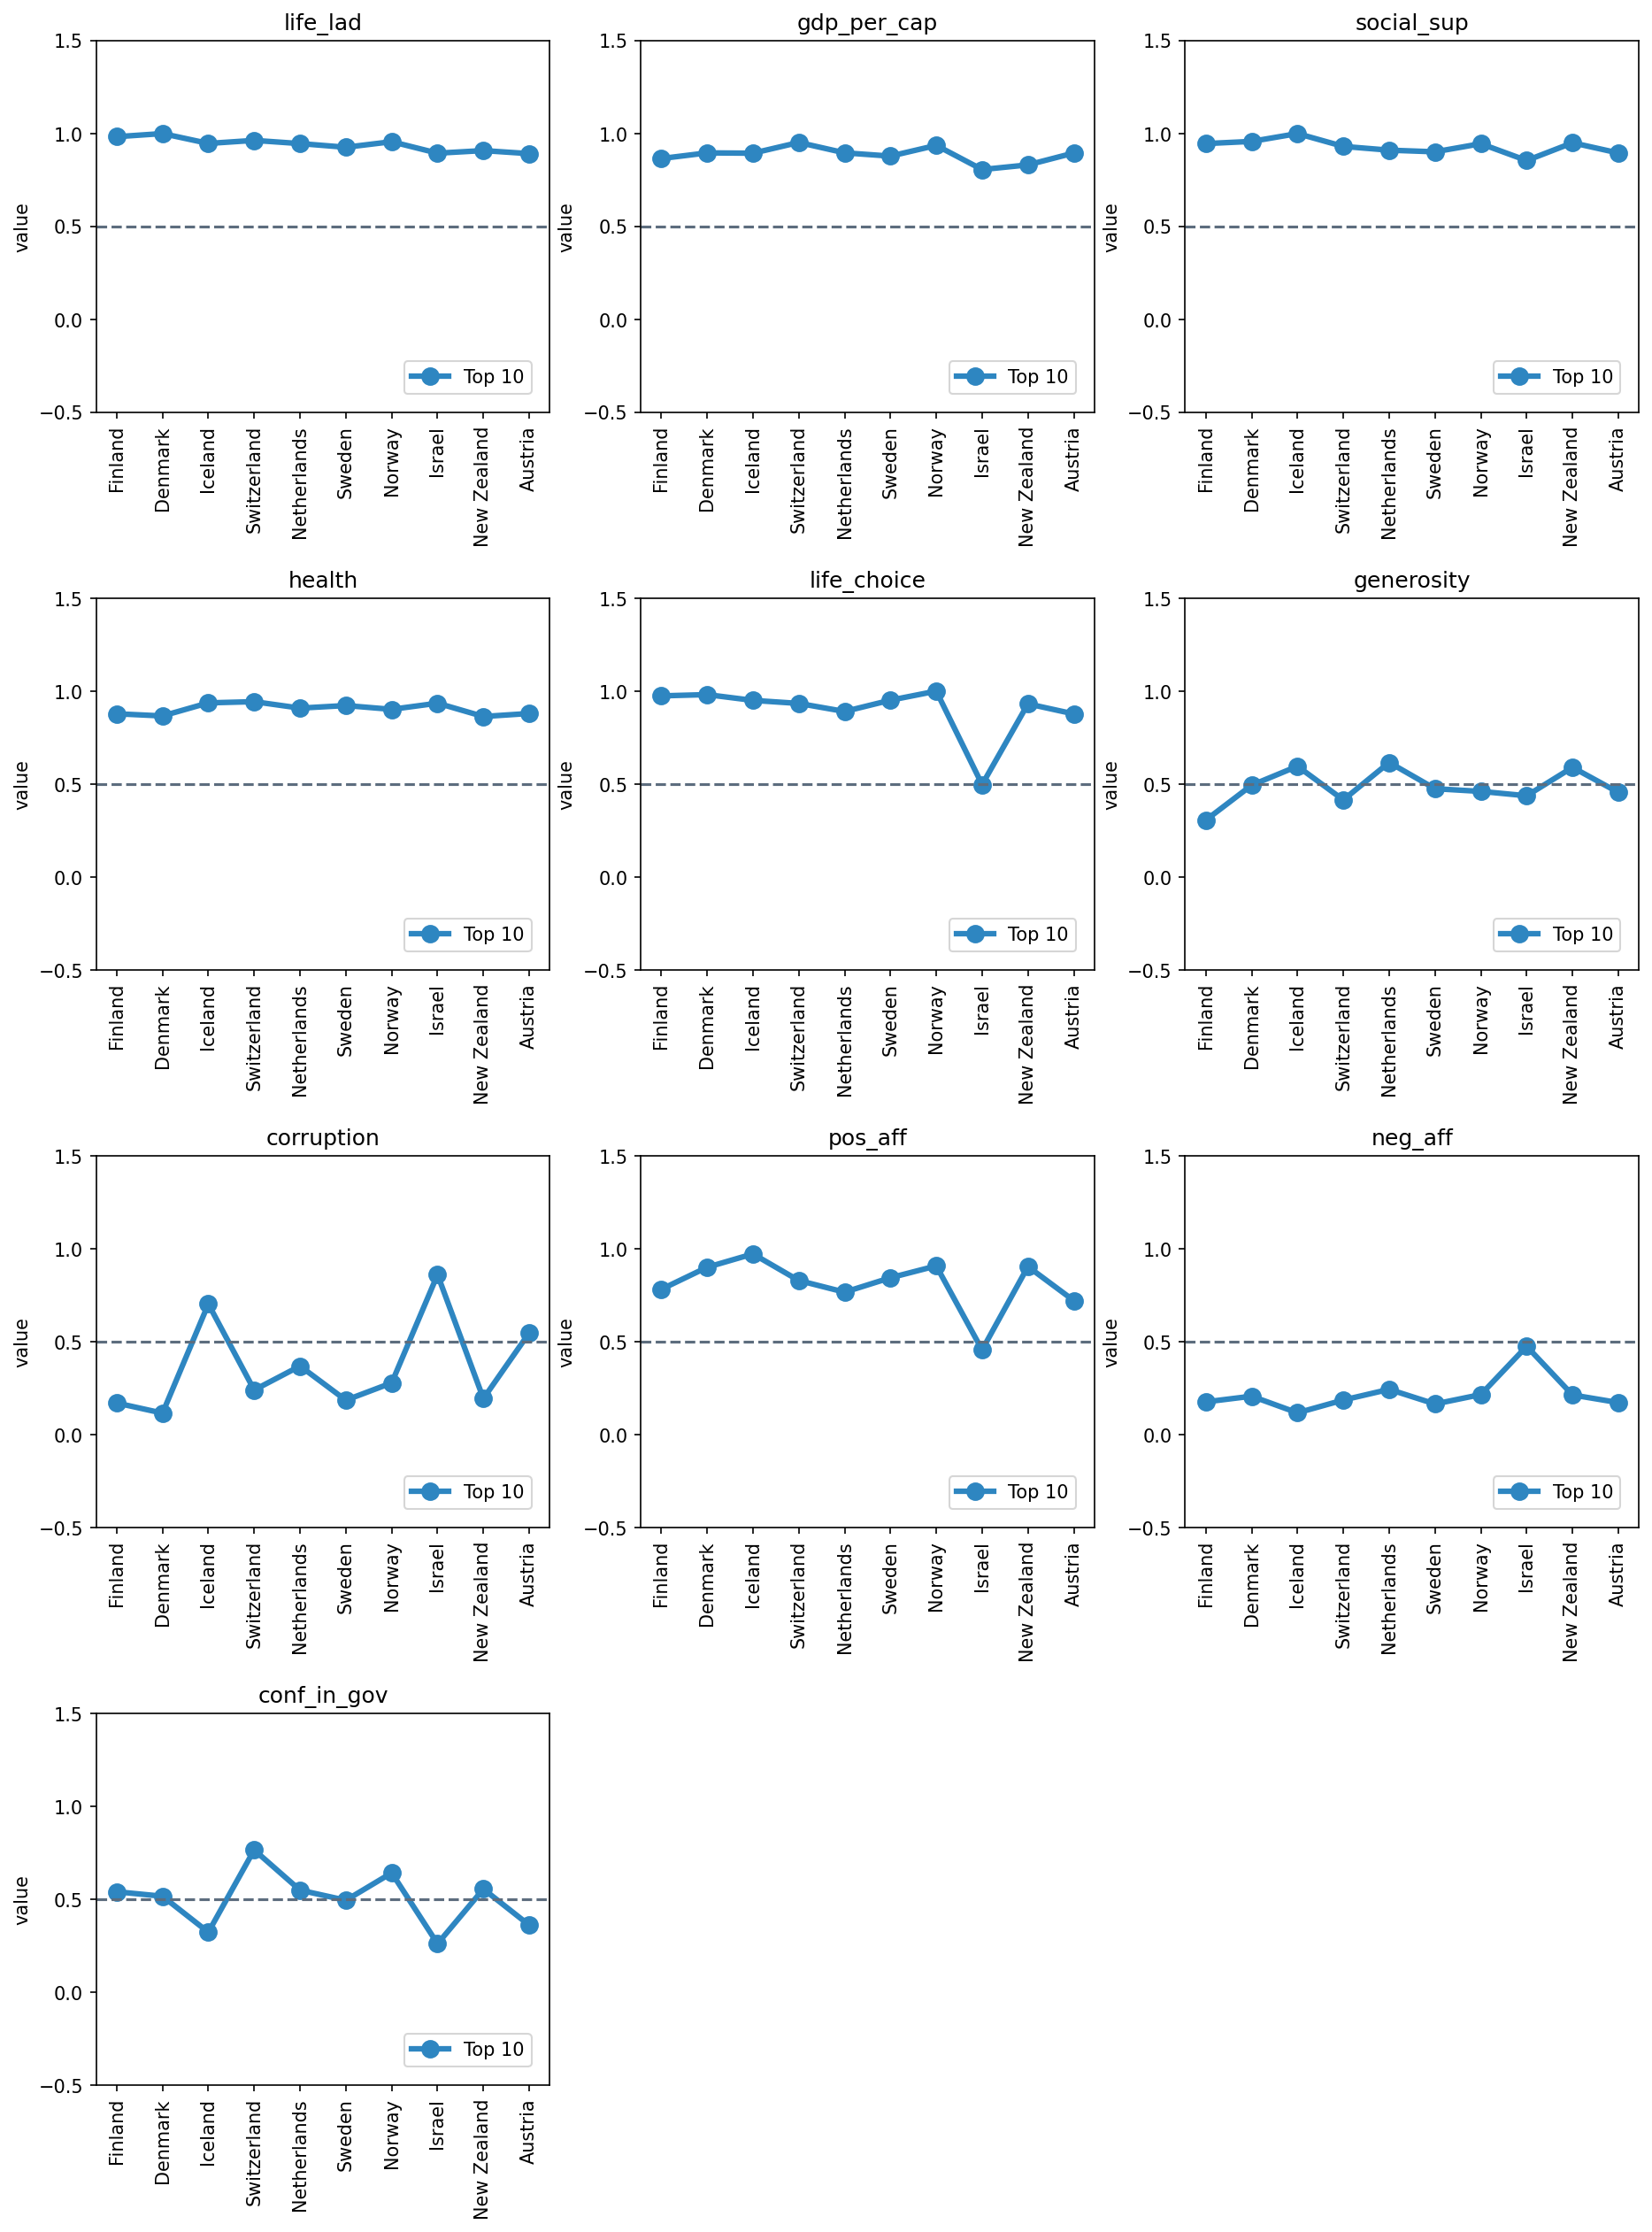

In [11]:
# Prepare DATA

df_w_overall.rename(columns={'Happiness score':'happiness_score'},inplace=True)

# for outlier keeper
wh = pd.merge(df_w_overall[['Country','happiness_score']],winner_df,left_on='Country',right_on='country_name',how='left')
wh = wh.rename(columns={'Country':'country'}).drop(columns=['country_name'])

# for non-outlier
wh_ol = pd.merge(df_w_overall[['Country','happiness_score']],winner_df_ol,left_on='Country',right_on='country_name',how='left')
wh_ol = wh_ol.rename(columns={'Country':'country'}).drop(columns=['country_name'])

print(f" \n{'-'*6} BEFORE Feature scaling {'-'*6}\n ")
display(wh)

# Feature scaling by min-max scaler

st_wh = wh.loc[wh['life_lad'].notna(),:].reset_index(drop=True)

st_wh.iloc[:,1:] = st_wh.iloc[:,1:].apply(lambda x: (x-x.min())/(x.max()-x.min()) )
define = st_wh.iloc[:10,:]
print(f" \n{'-'*6} AFTER Feature scaling by Min - Max scaler {'-'*6}\n ")
display(define)

# Plot

plt.style.use('default')

plt.figure(figsize=(15,20), dpi=150)

for i,j in enumerate(define) :
    if i >1 :
        plt.subplot(4, 3, i-1)
        plt.plot(define['country'], define[j],color='#2E86C1', marker='o', markersize = 9, 
        linewidth=3, linestyle='solid', alpha=1 ,label="Top 10" )
        plt.title(f"{j}")
        plt.xticks([0,1,2,3,4,5,6,7,8,9],rotation=90 )
        plt.ylabel("value")
        plt.legend(loc="lower right",borderaxespad=1 )
        plt.yticks([-0.5,0,0.5,1,1.5])
        plt.axhline(y=0.5, color='#5D6D7E', linestyle='--')
        plt.subplots_adjust( wspace=None, hspace=0.5 )

# Now we have features of the first 10th of happiest countries
By standardization, the range of value will not swing too much.
- the reference line at 0.5 means they are above or below the world mean

# But our question is " What the most happiness country looks like ? "
- it seems like this feature still cannot answer that clearly.
- so, we decide to use another tool

[Text(-6.41666666666668, 0.5, 'Variables')]

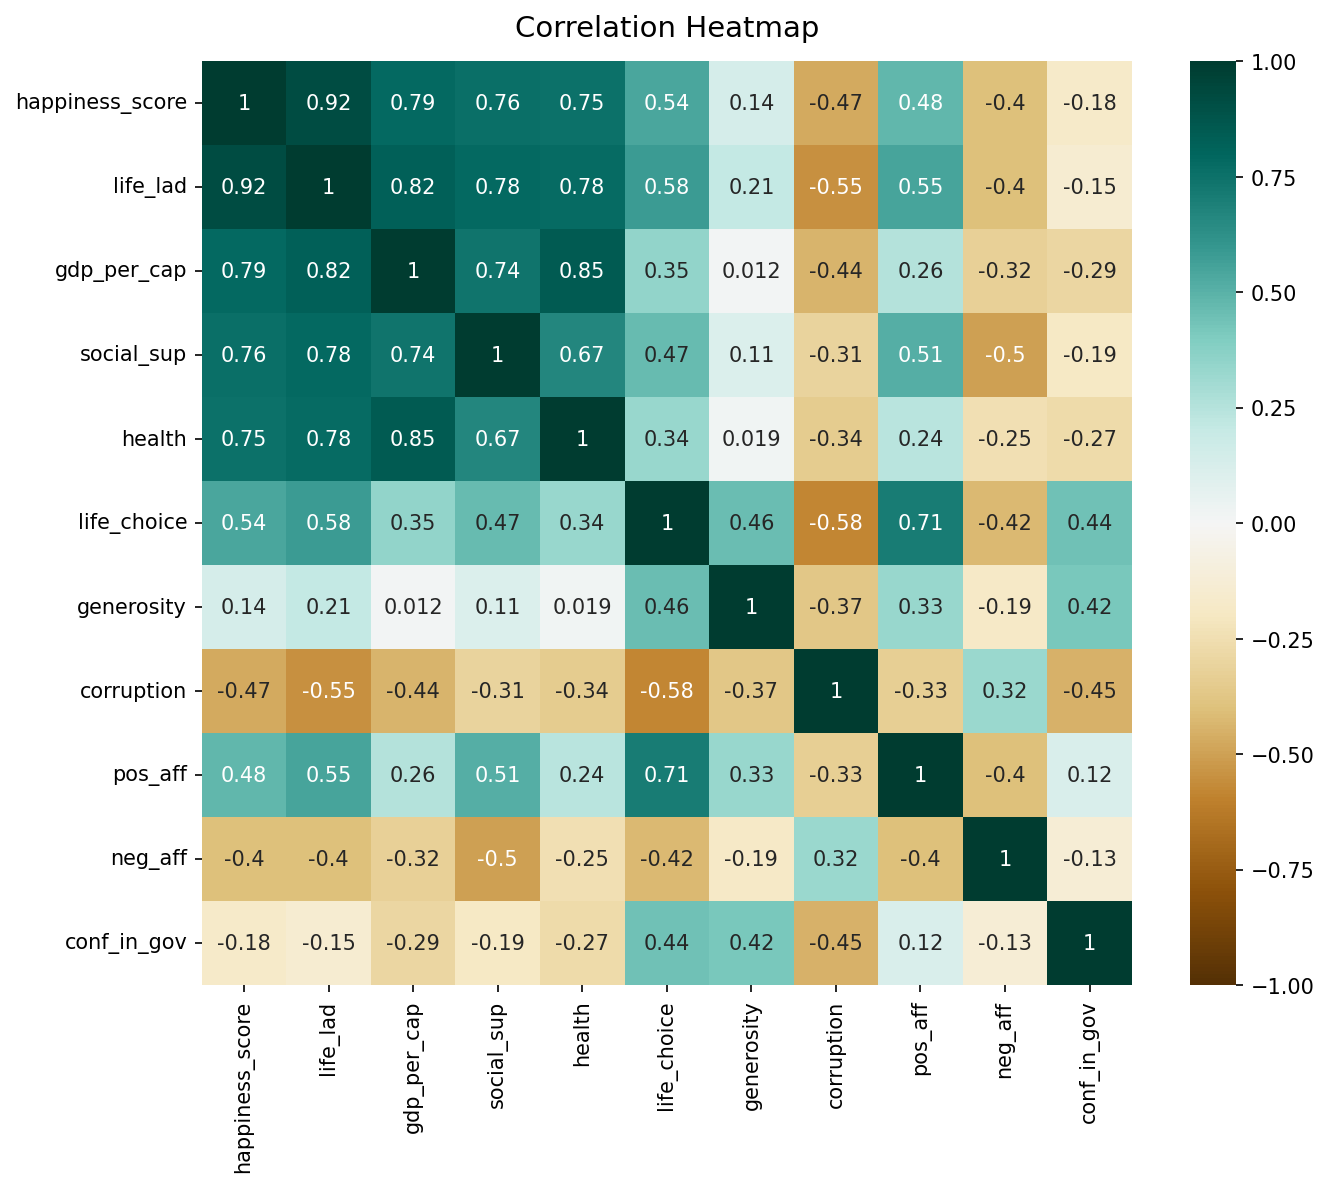

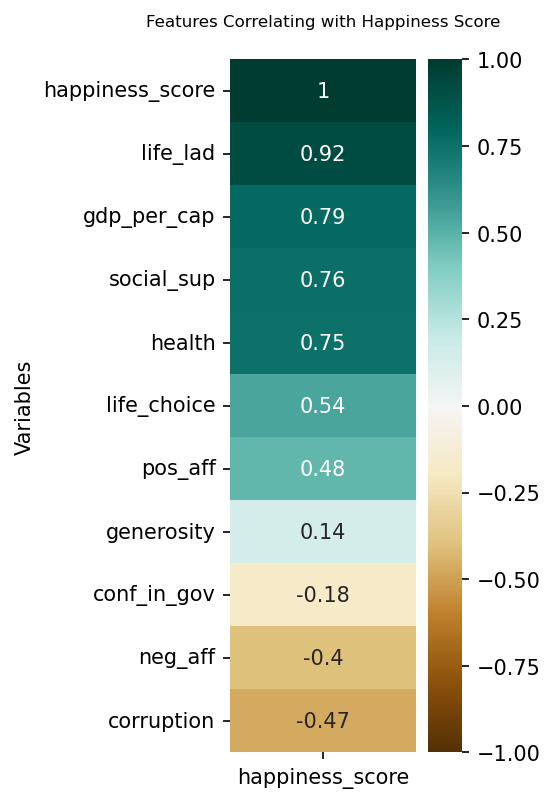

In [12]:
# Prepare DATA

nm_wh = wh_ol.reset_index(drop=True)

# To clarify the previous plot, we will use a correlation tool to find out which variables support the happiness score

nm_wh = nm_wh.iloc[:,1:]

# Increase the size of the heatmap.
plt.figure(figsize=(10, 8), dpi=150 )

heatmap = sns.heatmap(nm_wh.corr(), vmin=-1, vmax=1, annot=True , cmap='BrBG')
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)

plt.figure(figsize=(2, 6), dpi=150 )
heatmap = sns.heatmap(nm_wh.corr()[['happiness_score']].sort_values(by='happiness_score', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Features Correlating with Happiness Score', fontdict={'fontsize':8}, pad=16)
heatmap.set( ylabel='Variables')

# We can now say what the Happiest country should be by the graph
- Next step we will look at our country

,ranking,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
13,14,Germany,7.034,6.837668,10.816555,0.920723,70.305000,0.856771,0.082055,0.573579,0.699729,0.204836,0.516785
15,16,United States,6.977,7.081947,10.961868,0.920423,66.492187,0.841647,0.185710,0.688247,0.758199,0.262641,0.387333
16,17,United Kingdom,6.943,6.914552,10.694497,0.939660,69.658750,0.849158,0.306616,0.479071,0.730204,0.226115,0.410635
19,20,France,6.687,6.668876,10.675093,0.923638,71.537500,0.833298,-0.101873,0.628915,0.710316,0.254552,0.380175
26,27,Singapore,6.480,6.510156,11.333850,0.880581,72.774287,0.845741,0.068810,0.101037,0.646796,0.163161,0.902406
30,31,Italy,6.467,6.296656,10.643934,0.897003,71.410938,0.646264,-0.021581,0.904323,0.626451,0.318653,0.282485
53,54,Japan,6.039,6.020960,10.588077,0.902540,73.419062,0.804293,-0.167315,0.695123,0.698427,0.182751,0.319329
58,59,South Korea,5.935,5.889748,10.521626,0.792951,71.742187,0.638567,-0.052643,0.791622,0.579527,0.226342,0.311779
60,61,Thailand,5.891,6.059321,9.654315,0.889520,67.592186,0.874680,0.374681,0.911501,0.786996,0.190899,0.537601
71,72,China,5.585,5.098935,9.307982,0.789159,67.432813,0.849859,-0.159535,NaN,0.690938,0.168280,NaN




Thailand's ranking is 61 from 146 countries
Right here we will show you 70 countries descending by happiness score below : 




[Text(0.5, 0, 'Happiness Score'), Text(0, 0.5, 'Country')]

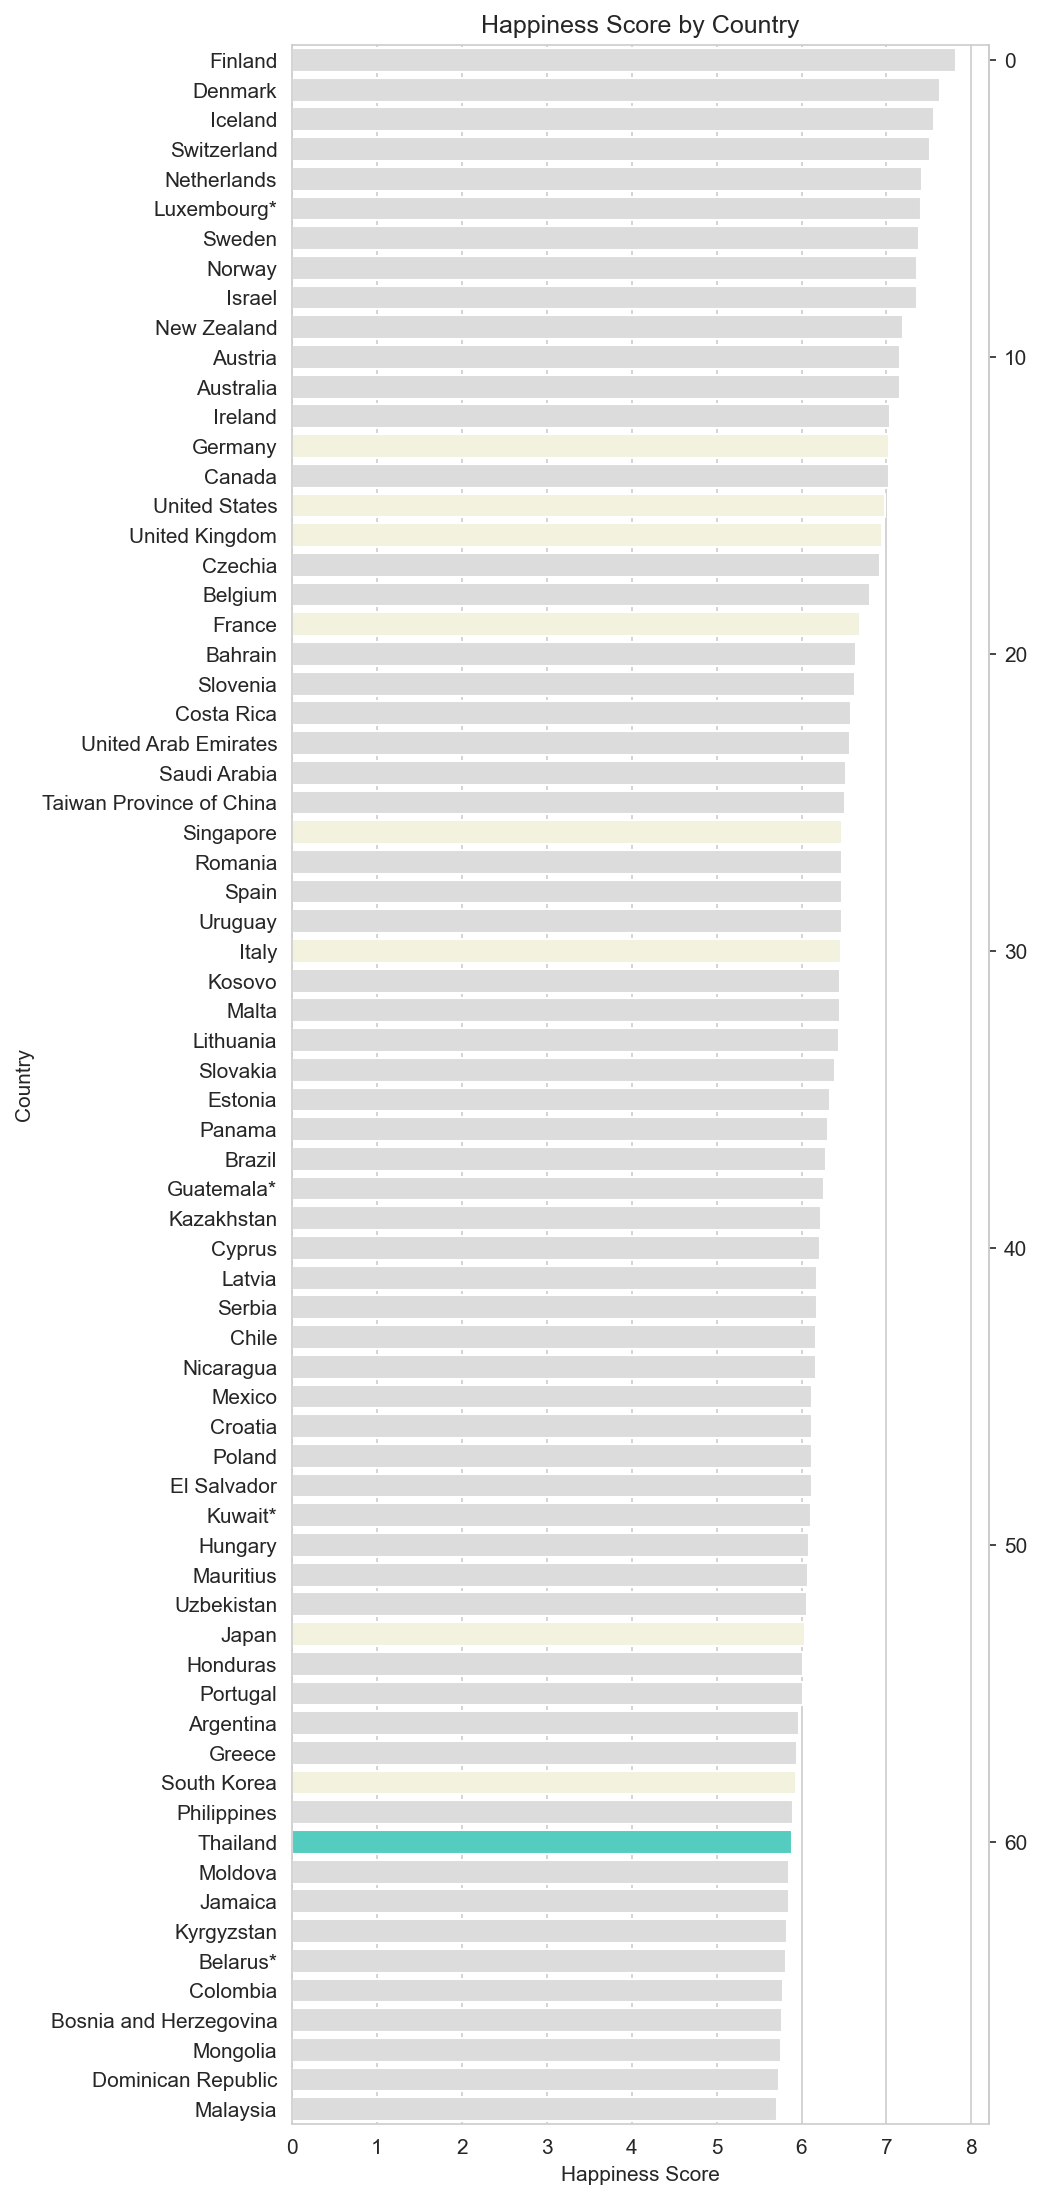

In [13]:
# Prepare DATA

rnk_wh = wh.reset_index(drop=False)

rnk_wh = rnk_wh.rename(columns={'index':'ranking'})
rnk_wh['ranking'] = rnk_wh['ranking'].apply( lambda x : x+1 )

# Find our country

scp = ['Thailand','United States','United Kingdom','France',"Germany",'Singapore','Italy','Japan','South Korea','Vietnam','Laos','Philipines','China']

display(rnk_wh.loc[rnk_wh['country'].isin(scp),:])
print(f"\n\nThailand's ranking is {rnk_wh.iloc[:61,:]['country'].count()} from {df_w_overall['Country'].count()-1} countries\n\
Right here we will show you 70 countries descending by happiness score below : \n\n")

# Plot

def set_custom_palette(series, max_color = 'turquoise' , sc_color = 'beige', other_color = 'gainsboro'):
    max_val = 5.891
    scope = [ 7.034,6.977,6.943,6.687,6.480,6.467,6.039,5.935 ]
    pal = []
    
    for item in series:
        if item == max_val:
            pal.append(max_color)
        elif item in scope:
            pal.append(sc_color)
        else:
            pal.append(other_color)
    return pal

sns.set_style("whitegrid")

plt.figure(figsize=(6,18), dpi=150 )
ax = sns.barplot(x = 'happiness_score', y = 'country', data=rnk_wh.iloc[:70,:], palette=set_custom_palette(rnk_wh.iloc[:70,:]['happiness_score']))
ax.set_title('Happiness Score by Country')
ax.secondary_yaxis("right" )
ax.set(xlabel='Happiness Score', ylabel= 'Country')


,ranking,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
4,5,Singapore,6.480,6.510156,11.333850,0.880581,72.774287,0.845741,0.068810,0.101037,0.646796,0.163161,0.902406
8,9,Japan,6.039,6.020960,10.588077,0.902540,73.419062,0.804293,-0.167315,0.695123,0.698427,0.182751,0.319329
9,10,South Korea,5.935,5.889748,10.521626,0.792951,71.742187,0.638567,-0.052643,0.791622,0.579527,0.226342,0.311779
10,11,Philippines,5.904,5.262097,8.827065,0.813253,61.764062,0.895261,-0.018194,0.778223,0.784309,0.340549,0.704757
11,12,Thailand,5.891,6.059321,9.654315,0.889520,67.592186,0.874680,0.374681,0.911501,0.786996,0.190899,0.537601
14,15,Malaysia,5.711,5.812250,10.023438,0.824846,65.500001,0.825721,0.108586,0.821053,0.725830,0.217987,0.716833
15,16,China,5.585,5.098935,9.307982,0.789159,67.432813,0.849859,-0.159535,NaN,0.690938,0.168280,NaN
16,17,Vietnam,5.485,5.330300,8.700916,0.822360,64.806250,0.889537,0.014862,0.787324,0.609056,0.216705,0.853416
17,18,Russia,5.459,5.516176,10.138076,0.898431,61.954687,0.669296,-0.212565,0.900183,0.587314,0.177973,0.496509
23,24,Laos,5.140,4.995433,8.681383,0.723901,58.722000,0.901149,0.247712,0.638897,0.731312,0.274435,0.919905




Thailand's ranking is 12 from 35 countries
Right here we will show you 70 countries descending by happiness score below : 




[Text(0.5, 0, 'Happiness Score'), Text(0, 0.5, 'Country')]

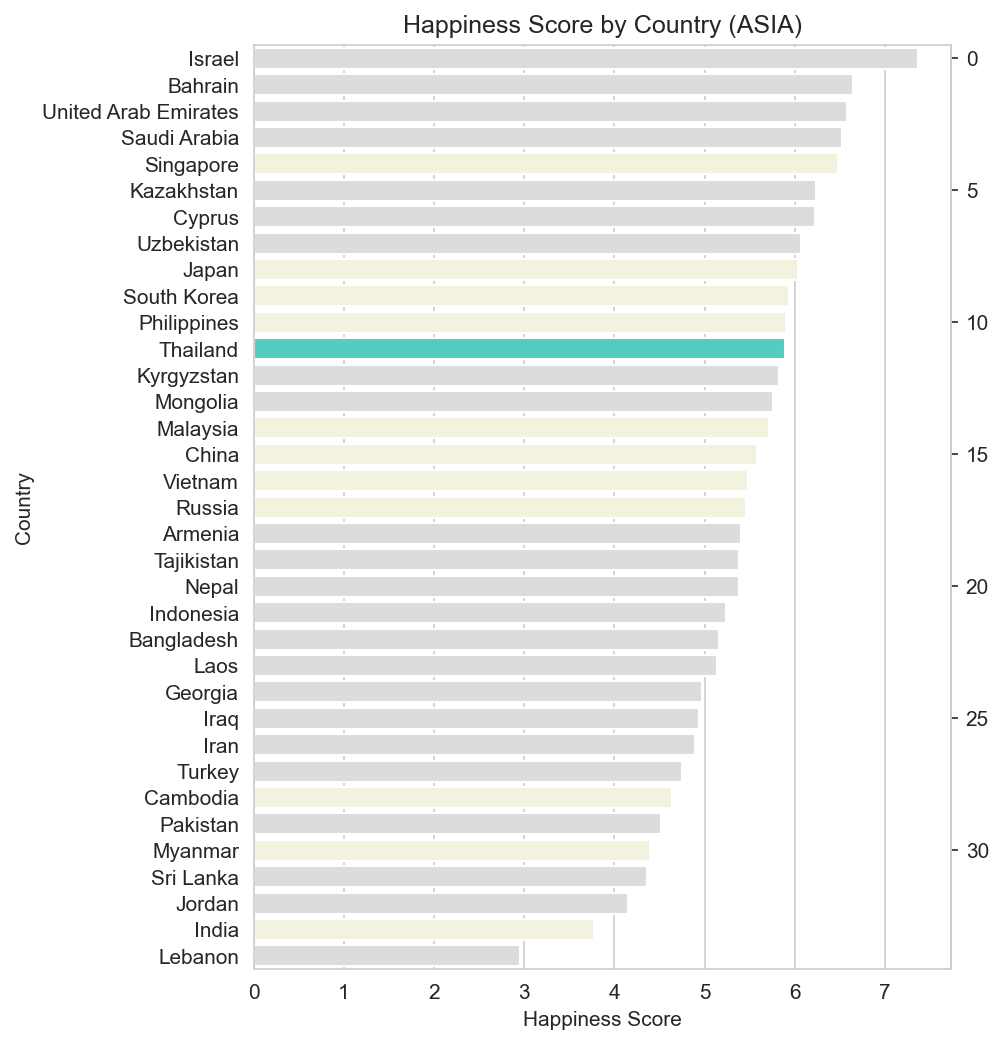

In [14]:
asia = [ 'Afganistan','Armenia','Azerbaijan','Bahrain','Bangladesh','Bhutan','Brunei','Cambodia','China',
'Cyprus','East Timor','Georgia','India','Indonesia','Iran','Iraq','Israel','Japan','Jordan','Kazakhstan',
'Kuwait','Kyrgyzstan','Laos','Lebanon','Malaysia','Maldives','Mongolia','Myanmar','Nepal','North Korea',
'Oman','Pakistan','Philippines','Qatar','Russia','Saudi Arabia','Singapore','South Korea','Sri Lanka','Syria',
'Tajikistan','Thailand','Turkey','Turkmenistan','United Arab Emirates','Uzbekistan','Vietnam','Yemen' ]

# Prepare Asia DATA

asia_wh = wh.loc[wh['country'].isin(asia),:].reset_index(drop=True)

asia_wh = asia_wh.reset_index(drop=False).rename(columns={'index':'ranking'})
asia_wh['ranking'] = asia_wh['ranking'].apply( lambda x : x+1 )

# scope interests

scp_asia = [ 'Thailand','Singapore','Vietnam','Laos','Russia','Philippines','Myanmar','Japan','Cambodia','China','South Korea' ,'Malaysia','India' ]

display(asia_wh.loc[asia_wh['country'].isin(scp_asia),:])
print(f"\n\nThailand's ranking is {asia_wh.iloc[:12,:]['country'].count()} from {asia_wh['country'].count()} countries\n\
Right here we will show you 70 countries descending by happiness score below : \n\n")

# Plot

def set_custom_palette2(series, max_color = 'turquoise' , sc_color = 'beige', other_color = 'gainsboro'):
    max_val = 5.891
    scope = [ 5.459,6.480,6.039,5.935,5.904,5.711,5.585,5.485,5.459,5.104,4.640,4.394,3.777 ]
    pal = []
    
    for item in series:
        if item == max_val:
            pal.append(max_color)
        elif item in scope:
            pal.append(sc_color)
        else:
            pal.append(other_color)
    return pal

sns.set_style("whitegrid")

plt.figure(figsize=(6,8), dpi=150 )
ax = sns.barplot(x = 'happiness_score', y = 'country', data=asia_wh, palette=set_custom_palette2(asia_wh['happiness_score']))
ax.set_title('Happiness Score by Country (ASIA)')
ax.secondary_yaxis("right" )
ax.set(xlabel='Happiness Score', ylabel= 'Country')

# What about 'Thailand' ?
we will compare between :
- Thailand ( our country )
- Finland ( The Happiest country in the world )

In [15]:
# find a country that has a happiness score around the median from normalized file (it means a happiness score of around 0.5)

st_wh.iloc[ 80:100,: ]

,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,neg_aff,conf_in_gov
80,Ivory Coast,0.522614,0.274186,0.328596,0.360673,0.201932,0.547205,0.249203,0.779348,0.517446,0.557680,0.526379
81,North Macedonia,0.515968,0.348108,0.597869,0.635157,0.685338,0.331286,0.317743,0.910020,0.223381,0.523753,0.245572
82,Albania,0.515968,0.366571,0.546909,0.482154,0.804476,0.373880,0.225810,0.908165,0.302659,0.455907,0.293735
83,South Africa,0.515045,0.338337,0.580055,0.789326,0.166083,0.526089,0.168442,0.878156,0.732295,0.269537,0.449424
84,Bangladesh,0.507846,0.299108,0.257508,0.268780,0.564384,0.545351,0.271178,0.756528,0.108972,0.383696,0.757427
85,Laos,0.505077,0.356787,0.385348,0.499148,0.420822,0.883875,0.586642,0.634177,0.761352,0.401182,0.957718
86,Algeria,0.501754,0.448220,0.536588,0.677583,0.710784,0.066147,0.147919,0.705404,0.244463,0.380198,NaN
87,Ukraine,0.494739,0.310322,0.554633,0.796201,0.591933,0.157779,0.190389,0.979747,0.272146,0.275475,0.000000
88,Morocco,0.490308,0.369297,0.424634,0.282754,0.600729,0.497533,0.066828,0.846809,0.410786,0.441260,0.356262
89,Mozambique,0.488093,0.295252,0.000000,0.537217,0.000000,0.536452,0.349797,0.733652,0.411221,0.535846,0.650950




------ we will compare 'Thailand ( our country )' vs 'Finland ( The Happiest country in the world )' vs 'Afghanistan ( The lowest happiness country in the world ) and 'Bangladesh (Median happiness)' ------ 


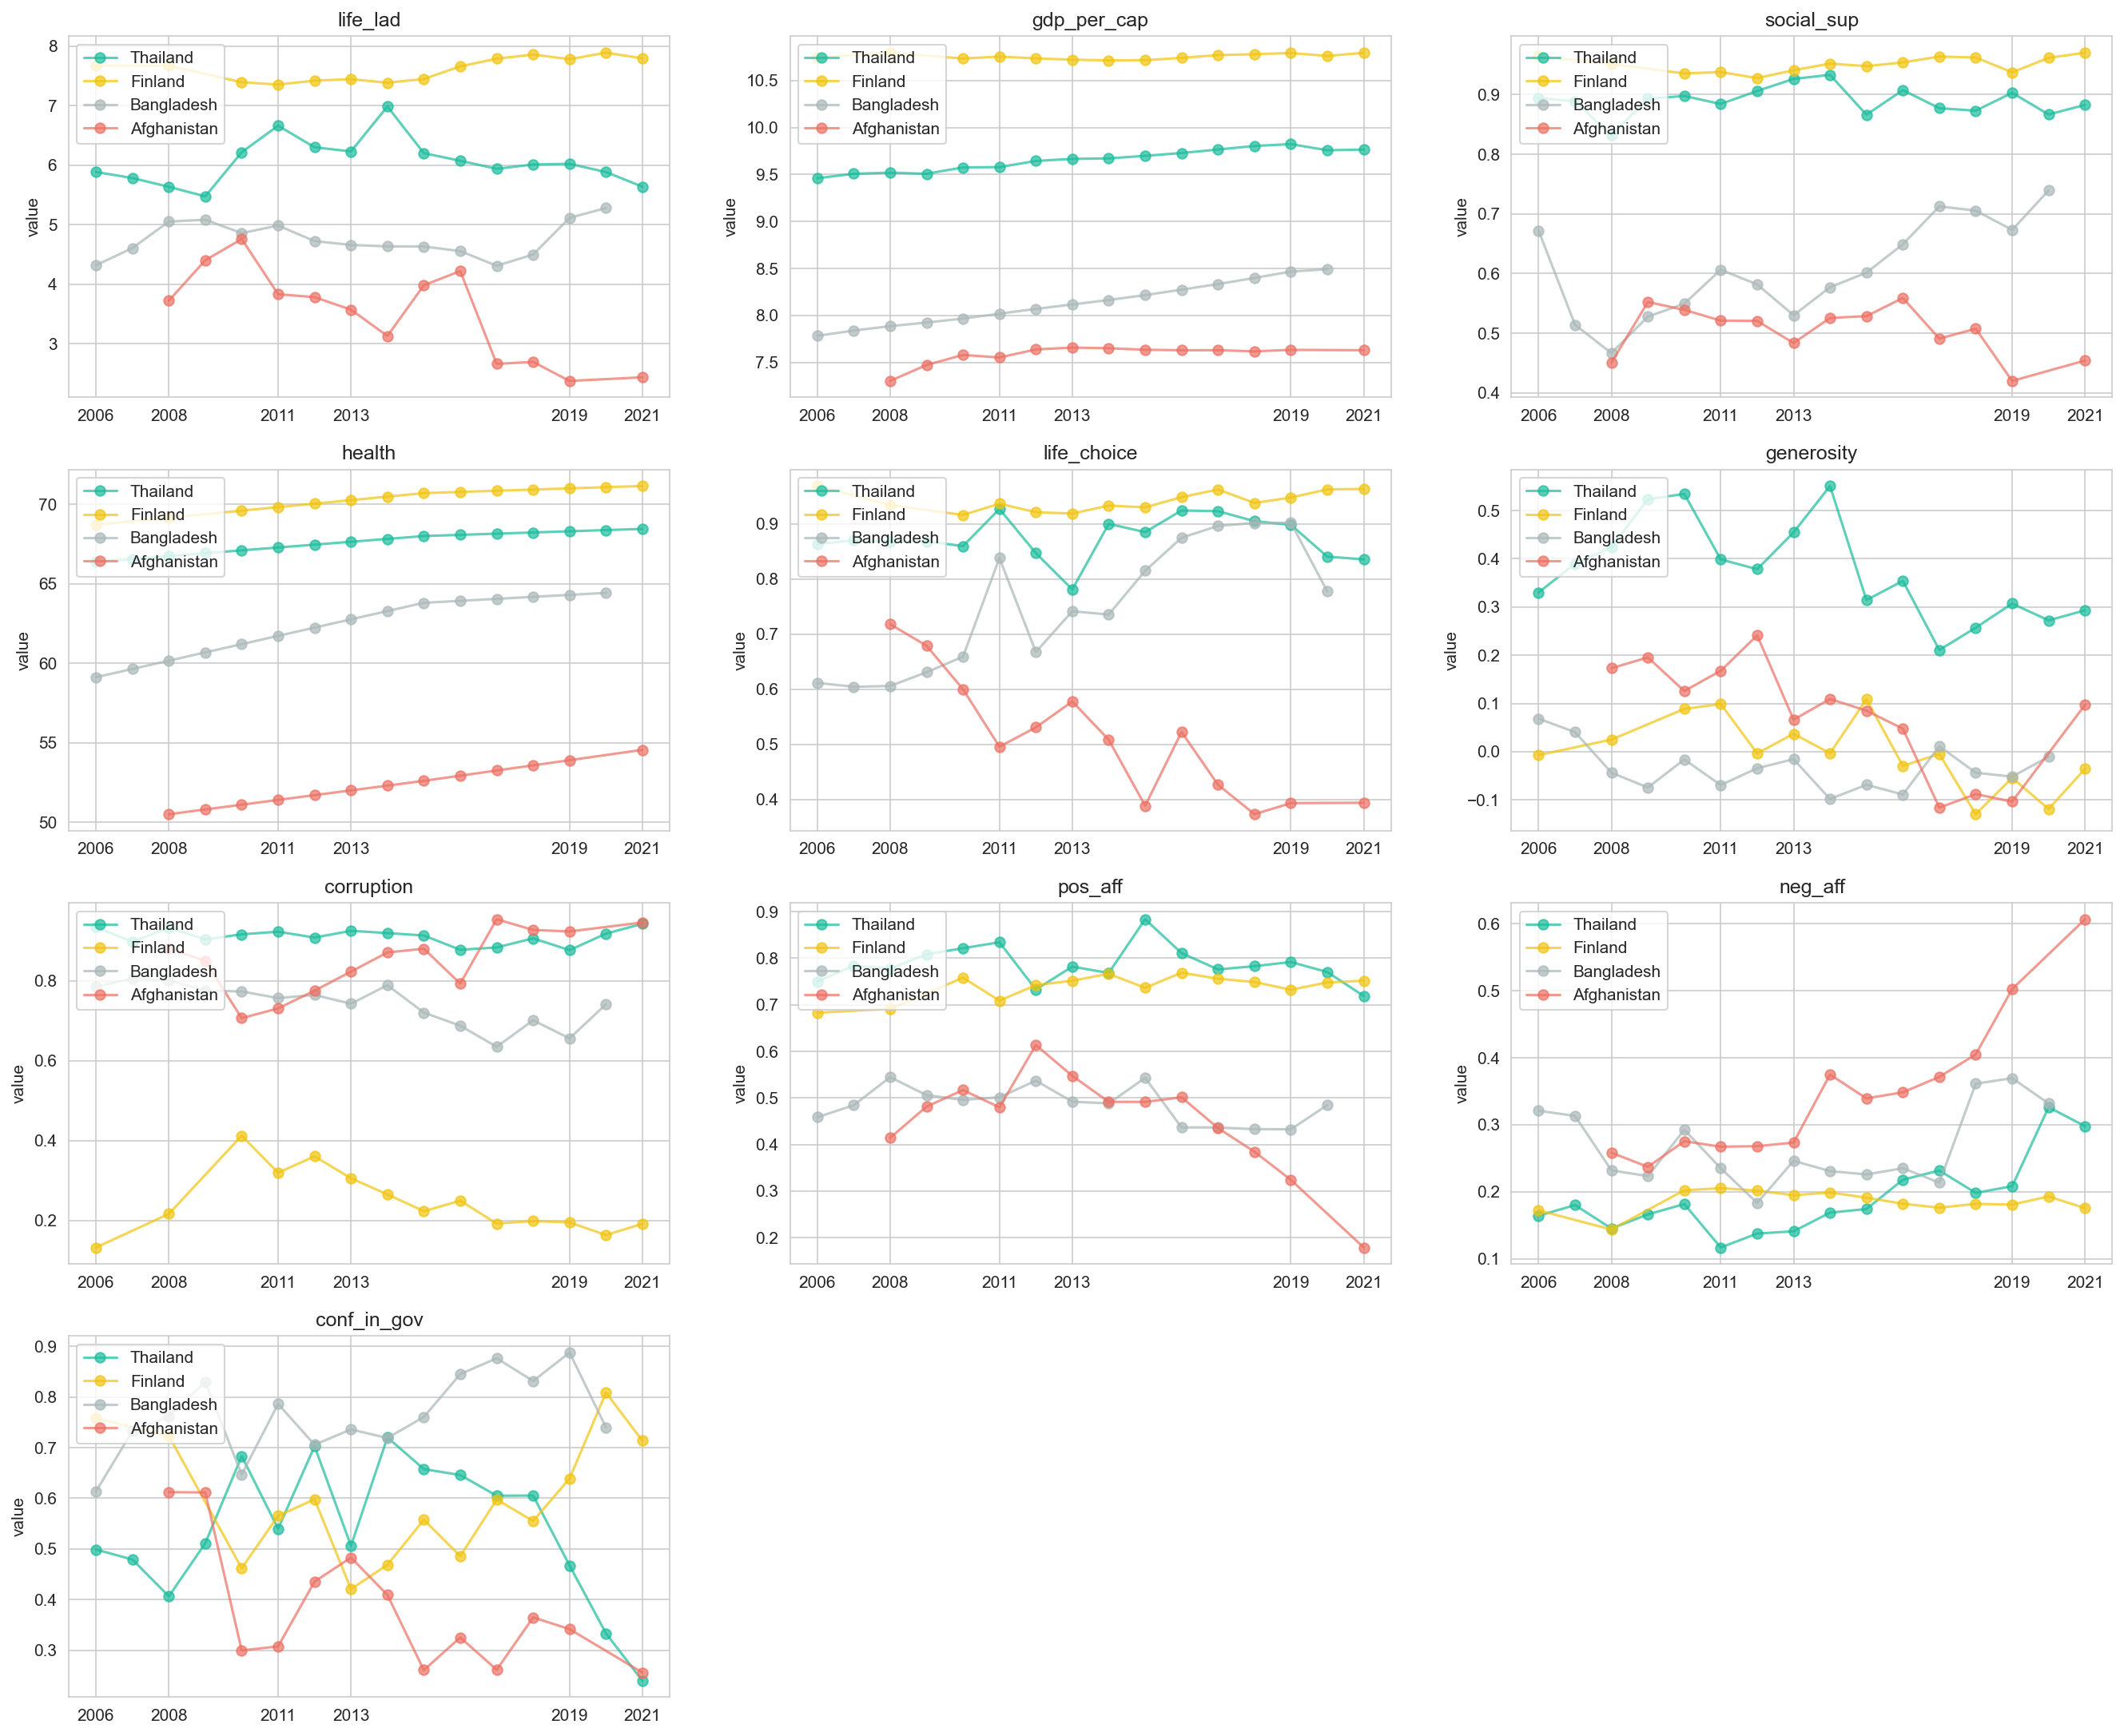

In [16]:
# Scope our interest

interest = ['Finland','Denmark','Iceland','Switzerland','Netherlands','Sweden','Thailand','Afghanistan','Laos','Bangladesh']

inter_df = df.loc[df['country_name'].isin(interest),:]

th_hp = inter_df.loc[inter_df['country_name']=='Thailand', : ]
fn_hp = inter_df.loc[inter_df['country_name']=='Finland', : ]
al_hp = inter_df.loc[inter_df['country_name']=='Bangladesh', : ]
af_hp = inter_df.loc[inter_df['country_name']=='Afghanistan', : ]

print(f"\n\n{'-'*6} we will compare \'Thailand ( our country )\' vs \'Finland ( The Happiest country in the world )\' vs \
\'Afghanistan ( The lowest happiness country in the world ) and \'Bangladesh (Median happiness)\' {'-'*6} ")

# PLOT

plt.style.use('fast')

plt.figure(figsize=(22,18), dpi=150)

for i,j in enumerate(th_hp) :
    if i >1 :
        plt.subplot(4, 3, i-1)
        plt.plot(th_hp['year'], th_hp[j],color='#1ABC9C', marker='o', linestyle='solid', alpha=0.7 ,label="Thailand" )
        plt.plot(fn_hp['year'], fn_hp[j],color='#F1C40F', marker='o', linestyle='solid', alpha=0.7 ,label="Finland" )
        plt.plot(al_hp['year'], al_hp[j],color='#AAB7B8', marker='o', linestyle='solid', alpha=0.7 ,label="Bangladesh" )
        plt.plot(af_hp['year'], af_hp[j],color='#EC7063', marker='o', linestyle='solid', alpha=0.7 ,label="Afghanistan" )
        plt.title(f"{j}");plt.xticks([0,2,5,7,13,15]);plt.ylabel("value");plt.legend(loc="upper left")



now, what's next? <br>
We will gain insights from other files

In [17]:
# import another DATA

#wdi = pd.read_csv('https://media.githubusercontent.com/media/HikariJadeEmpire/TH_WLRD_Happiness_Project/main/WDI_CSV/WDIData.csv') # in case you working on GitHubCodespace
#wdi = pd.read_csv('~/Documents/DATAScience/Github/TH_WLRD_Happiness_Project/WDI_CSV/WDIData.csv') # for mac
wdi = pd.read_csv('D:\DATA Science\DATASET\World_Happiness\WDI_CSV\WDIData.csv') # for Windows

# rename the column of the WDI file

wdi.rename(columns={ 'Country Name':'country_name','Country Code':'country_code','Indicator Name':'indicator_name','Indicator Code':'indicator_code' },inplace=True )

# Scope our interests

selection = [ 'Access to electricity (% of population)','Access to clean fuels and technologies for cooking (% of population)','Death rate, crude (per 1,000 people)',
             'Birth rate, crude (per 1,000 people)','Suicide mortality rate (per 100,000 population)','Electric power consumption (kWh per capita)',
              'Forest area (% of land area)','PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)','Population growth (annual %)',
              'Population, female (% of total population)','Population, male (% of total population)','Population, total','Trade (% of GDP)',
              'Unemployment, total (% of total labor force) (national estimate)','Urban population (% of total population)',
              'Population density (people per sq. km of land area)','Rural population (% of total population)',
               'Domestic private health expenditure per capita (current US$)','Current health expenditure per capita (current US$)' ]

df_wdi = wdi.loc[ wdi['indicator_name'].isin(selection) ,['country_name','indicator_name','2006','2007','2008','2009','2010','2011','2012','2013','2014','2015'
                                                          ,'2016','2017','2018','2019','2020','2021' ] ]

display( df_wdi.info() )

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5054 entries, 0 to 383543
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_name    5054 non-null   object 
 1   indicator_name  5054 non-null   object 
 2   2006            4381 non-null   float64
 3   2007            4380 non-null   float64
 4   2008            4378 non-null   float64
 5   2009            4392 non-null   float64
 6   2010            4651 non-null   float64
 7   2011            4644 non-null   float64
 8   2012            4652 non-null   float64
 9   2013            4646 non-null   float64
 10  2014            4663 non-null   float64
 11  2015            4446 non-null   float64
 12  2016            4449 non-null   float64
 13  2017            4460 non-null   float64
 14  2018            4208 non-null   float64
 15  2019            4212 non-null   float64
 16  2020            3478 non-null   float64
 17  2021            1902 non-null  

None

In [18]:
# take a look and filter

yearss = [ '2006','2007','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021' ]

wdi_pv = df_wdi.melt( id_vars=['country_name','indicator_name'], value_vars=yearss )
wdi_pv.rename(columns={ 'variable':'year' },inplace=True )

# separate grouped file (just for look)

wdi_pv_look = wdi_pv.pivot_table( index=['country_name','year'], columns=['indicator_name'], values='value' )

print( f" \n{'-'*6} List of scope column {'-'*6}\n\n " )
display( wdi_pv_look.info() )
display( wdi_pv_look )


 
------ List of scope column ------

 
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 4240 entries, ('Afghanistan', '2006') to ('Zimbabwe', '2021')
Data columns (total 19 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   Access to clean fuels and technologies for cooking (% of population)    3566 non-null   float64
 1   Access to electricity (% of population)                                 3949 non-null   float64
 2   Birth rate, crude (per 1,000 people)                                    3878 non-null   float64
 3   Current health expenditure per capita (current US$)                     3292 non-null   float64
 4   Death rate, crude (per 1,000 people)                                    3876 non-null   float64
 5   Domestic private health expenditure per capita (current US$)            3292 non-null   float64
 6   El

None

indicator_name     Access to clean fuels and technologies for cooking (% of population)  \
country_name year                                                                         
Afghanistan  2006                                              13.85                      
             2007                                              15.30                      
             2008                                              16.70                      
             2009                                              18.40                      
             2010                                              20.00                      
...                                                              ...                      
Zimbabwe     2017                                              29.80                      
             2018                                              29.90                      
             2019                                              30.10                      
             2020                                              30.40                      
             2021                                                NaN                      

indicator_name     Access to electricity (% of population)  \
country_name year                                            
Afghanistan  2006                                30.718691   
             2007                                36.051010   
             2008                                42.400002   
             2009                                46.740051   
             2010                                42.700001   
...                                                    ...   
Zimbabwe     2017                                44.178635   
             2018                                45.572647   
             2019                                46.781475   
             2020                                52.747669   
             2021                                      NaN   

indicator_name     Birth rate, crude (per 1,000 people)  \
country_name year                                         
Afghanistan  2006                                44.721   
             2007                                43.858   
             2008                                41.506   
             2009                                41.157   
             2010                                40.602   
...                                                 ...   
Zimbabwe     2017                                32.516   
             2018                                32.074   
             2019                                31.518   
             2020                                31.009   
             2021                                   NaN   

indicator_name     Current health expenditure per capita (current US$)  \
country_name year                                                        
Afghanistan  2006                                          27.836571     
             2007                                          31.271839     
             2008                                          38.102661     
             2009                                          41.722744     
             2010                                          44.990532     
...                                                              ...     
Zimbabwe     2017                                         115.646201     
             2018                                         141.369308     
             2019                                         103.028272     
             2020                                                NaN     
             2021                                                NaN     

indicator_name     Death rate, crude (per 1,000 people)  \
country_name year                                         
Afghanistan  2006                                 9.679   
             2007                                 9.359   
             2008                         

In [19]:
# Prepare DATA

new_df = df

# Topic selection and rename columns

newname = [ 'acc_to_clnfuels_per','acc_to_electrics_per','birth_r','al_hlth_expend','death_r','dm_hlth_expend','electric_consump','forest_area_per',
'pm25','pop_dens','pop_growth','pop_f_per','pop_m_per','pop_total','pop_rural_per','suicide','trade_per_gdp','unemploy','pop_urban_per' ]

for i in range(len(newname)):
    pm25 = wdi_pv[ wdi_pv['indicator_name'] == selection[i]].groupby('country_name',group_keys=False).apply( lambda x: x.sort_values(by='year') )
    pm25 = pm25.loc[:,['country_name','year','value']]

    new_df = pd.merge( new_df,pm25,left_on=['country_name','year'],right_on=['country_name','year'] ).rename( columns={'value':newname[i]} )

print(f" \n\n{'-'*4} DATA Before clean {'-'*4}\n\n ")
display(new_df.info())


 

---- DATA Before clean ----

 
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1830 entries, 0 to 1829
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country_name          1830 non-null   object 
 1   year                  1830 non-null   object 
 2   life_lad              1830 non-null   float64
 3   gdp_per_cap           1825 non-null   float64
 4   social_sup            1829 non-null   float64
 5   health                1815 non-null   float64
 6   life_choice           1830 non-null   float64
 7   generosity            1825 non-null   float64
 8   corruption            1801 non-null   float64
 9   pos_aff               1828 non-null   float64
 10  neg_aff               1829 non-null   float64
 11  conf_in_gov           1741 non-null   float64
 12  acc_to_clnfuels_per   1718 non-null   float64
 13  acc_to_electrics_per  1686 non-null   float64
 14  birth_r               1724 non-null   

None

In [20]:
newdf_ol_b = new_df

# drop outliers

Q1 = newdf_ol_b.iloc[:,2:].quantile(0.25)
Q3 = newdf_ol_b.iloc[:,2:].quantile(0.75)
IQR = Q3 - Q1

newdf_ol = newdf_ol_b.loc[ :,['country_name','year'] ]
for i,j in enumerate(newdf_ol_b):
    if i > 1 :
        min_outlier = (Q1[j] - 1.5 * IQR[j]) ; max_outlier = (Q3[j] + 1.5 * IQR[j])

        newdf_ol_0 = newdf_ol_b.loc[ (newdf_ol_b[j] >= min_outlier)|(newdf_ol_b[j] <= max_outlier) ,['country_name','year',j]  ]
        newdf_ol = pd.merge(newdf_ol,newdf_ol_0,left_on=['country_name','year'],right_on=['country_name','year'],how='left')

print( f" {'-'*6} here is the DATA that clears out outliers {'-'*6} " )
display(newdf_ol)

 ------ here is the DATA that clears out outliers ------ 


,country_name,year,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,...,pop_dens,pop_growth,pop_f_per,pop_m_per,pop_total,pop_rural_per,suicide,trade_per_gdp,unemploy,pop_urban_per
0,Afghanistan,2008,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,...,49.525460,50.474536,26427199.0,NaN,2.49,23.320,40.518221,76.680,28.730696,38.102661
1,Afghanistan,2009,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,...,49.505857,50.494146,27385307.0,NaN,NaN,23.528,41.987193,76.472,30.365497,41.722744
2,Afghanistan,2010,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,...,49.483708,50.516292,28189672.0,NaN,NaN,23.737,43.220447,76.263,35.541016,44.990532
3,Afghanistan,2011,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,...,49.467665,50.532335,29249157.0,NaN,NaN,23.948,44.844851,76.052,37.252797,50.853474
4,Afghanistan,2012,3.782938,7.637953,0.520637,51.700001,0.530935,0.241247,0.775620,0.613513,...,49.455577,50.544420,30466479.0,NaN,1.69,24.160,46.711251,75.840,38.315901,51.440262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1825,Zimbabwe,2017,3.638300,8.241609,0.754147,52.150002,0.752826,-0.113937,0.751208,0.733641,...,52.948393,47.051613,14751101.0,50.029712,NaN,32.237,38.131320,67.763,52.362440,115.646201
1826,Zimbabwe,2018,3.616480,8.274620,0.775388,52.625000,0.762675,-0.084747,0.844209,0.657524,...,52.923755,47.076238,15052184.0,54.550270,NaN,32.209,38.909614,67.791,60.461669,141.369308
1827,Zimbabwe,2019,2.693523,8.196998,0.759162,53.099998,0.631908,-0.081540,0.830652,0.658434,...,52.900198,47.099796,15354608.0,52.687570,7.37,32.210,39.691374,67.790,54.413790,103.028272
1828,Zimbabwe,2020,3.159802,8.117733,0.717243,53.575001,0.643303,-0.029376,0.788523,0.660658,...,52.869327,47.130679,15669666.0,54.650561,NaN,32.242,40.505793,67.758,NaN,NaN


In [21]:
# Replace NaN by median respect to country

for j,name in enumerate(list(new_df)):
    if j > 2 :
        new_df[name].fillna(newdf_ol.groupby(['country_name'])[name].transform('median'),inplace=True)

print(f" \n\n{'-'*4} DATA After clean {'-'*4}\n\n ")
display(new_df.info())

new_df.head()

 

---- DATA After clean ----

 
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1830 entries, 0 to 1829
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country_name          1830 non-null   object 
 1   year                  1830 non-null   object 
 2   life_lad              1830 non-null   float64
 3   gdp_per_cap           1825 non-null   float64
 4   social_sup            1829 non-null   float64
 5   health                1815 non-null   float64
 6   life_choice           1830 non-null   float64
 7   generosity            1825 non-null   float64
 8   corruption            1801 non-null   float64
 9   pos_aff               1828 non-null   float64
 10  neg_aff               1829 non-null   float64
 11  conf_in_gov           1741 non-null   float64
 12  acc_to_clnfuels_per   1830 non-null   float64
 13  acc_to_electrics_per  1794 non-null   float64
 14  birth_r               1830 non-null   f

None

,country_name,year,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,...,pop_dens,pop_growth,pop_f_per,pop_m_per,pop_total,pop_rural_per,suicide,trade_per_gdp,unemploy,pop_urban_per
0,Afghanistan,2008,3.723590,7.302574,0.450662,50.500000,0.718114,0.173169,0.881686,0.414297,...,49.525460,50.474536,26427199.0,NaN,2.49,23.320,40.518221,76.680,28.730696,38.102661
1,Afghanistan,2009,4.401778,7.472446,0.552308,50.799999,0.678896,0.195469,0.850035,0.481421,...,49.505857,50.494146,27385307.0,NaN,5.20,23.528,41.987193,76.472,30.365497,41.722744
2,Afghanistan,2010,4.758381,7.579183,0.539075,51.099998,0.600127,0.125859,0.706766,0.516907,...,49.483708,50.516292,28189672.0,NaN,5.20,23.737,43.220447,76.263,35.541016,44.990532
3,Afghanistan,2011,3.831719,7.552006,0.521104,51.400002,0.495901,0.167723,0.731109,0.479835,...,49.467665,50.532335,29249157.0,NaN,5.20,23.948,44.844851,76.052,37.252797,50.853474
4,Afghanistan,2012,3.782938,7.637953,0.520637,51.700001,0.530935,0.241247,0.775620,0.613513,...,49.455577,50.544420,30466479.0,NaN,1.69,24.160,46.711251,75.840,38.315901,51.440262


# Are the other topics causing Happiness?
- we will do the correlation again

,country,happiness_score,life_lad,gdp_per_cap,social_sup,health,life_choice,generosity,corruption,pos_aff,...,pop_dens,pop_growth,pop_f_per,pop_m_per,pop_total,pop_rural_per,suicide,trade_per_gdp,unemploy,pop_urban_per
0,Finland,7.821,7.611299,10.753935,0.950494,70.325358,0.941380,-0.001996,0.244848,0.738809,...,50.794787,49.205209,5.445463e+06,76.997102,7.931429,84.809000,17.893079,15.191000,923.109873,4389.614746
1,Denmark,7.636,7.658959,10.887545,0.955379,70.147000,0.942618,0.165917,0.196148,0.784120,...,50.361819,49.638185,5.661270e+06,102.576047,6.031333,87.345267,141.182720,12.654733,959.218525,5984.363957
2,Iceland,7.557,7.459697,10.878041,0.977832,71.816666,0.930586,0.255945,0.696809,0.810800,...,49.283400,50.716567,3.412327e+05,87.615472,4.440000,93.725889,3.359591,6.274111,906.266725,4907.813895
3,Switzerland,7.512,7.528177,11.127461,0.942772,71.978181,0.923328,0.094757,0.304179,0.756787,...,50.544821,49.455181,8.268366e+06,120.780656,4.632727,73.746273,208.139480,26.253727,6015.246574,8825.632595
4,Netherlands,7.415,7.455590,10.891656,0.931476,71.126786,0.904320,0.273811,0.402404,0.735410,...,50.418896,49.581105,1.694377e+07,147.381594,5.086429,89.462714,501.457668,10.537286,1730.439290,5190.733968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Rwanda*,3.268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,Zimbabwe,2.995,3.837182,8.086318,0.792329,48.448437,0.592836,-0.100058,0.838707,0.651847,...,52.948081,47.051918,1.387388e+07,67.160851,5.836667,32.793250,35.498424,67.206750,53.200943,107.654599
144,Lebanon,2.955,4.604197,9.672203,0.735715,65.657000,0.600895,-0.011327,0.905361,0.444706,...,50.684741,49.315261,5.565741e+06,80.510638,8.825000,87.956800,543.872909,12.043200,309.131617,571.477823
145,Afghanistan,2.404,3.505506,7.586585,0.504086,52.353846,0.508496,0.077007,0.851207,0.450821,...,49.457745,50.542255,3.265878e+07,NaN,5.817500,24.637615,49.121813,75.362385,41.678055,55.146591


[Text(-4.41666666666668, 0.5, 'Variables')]

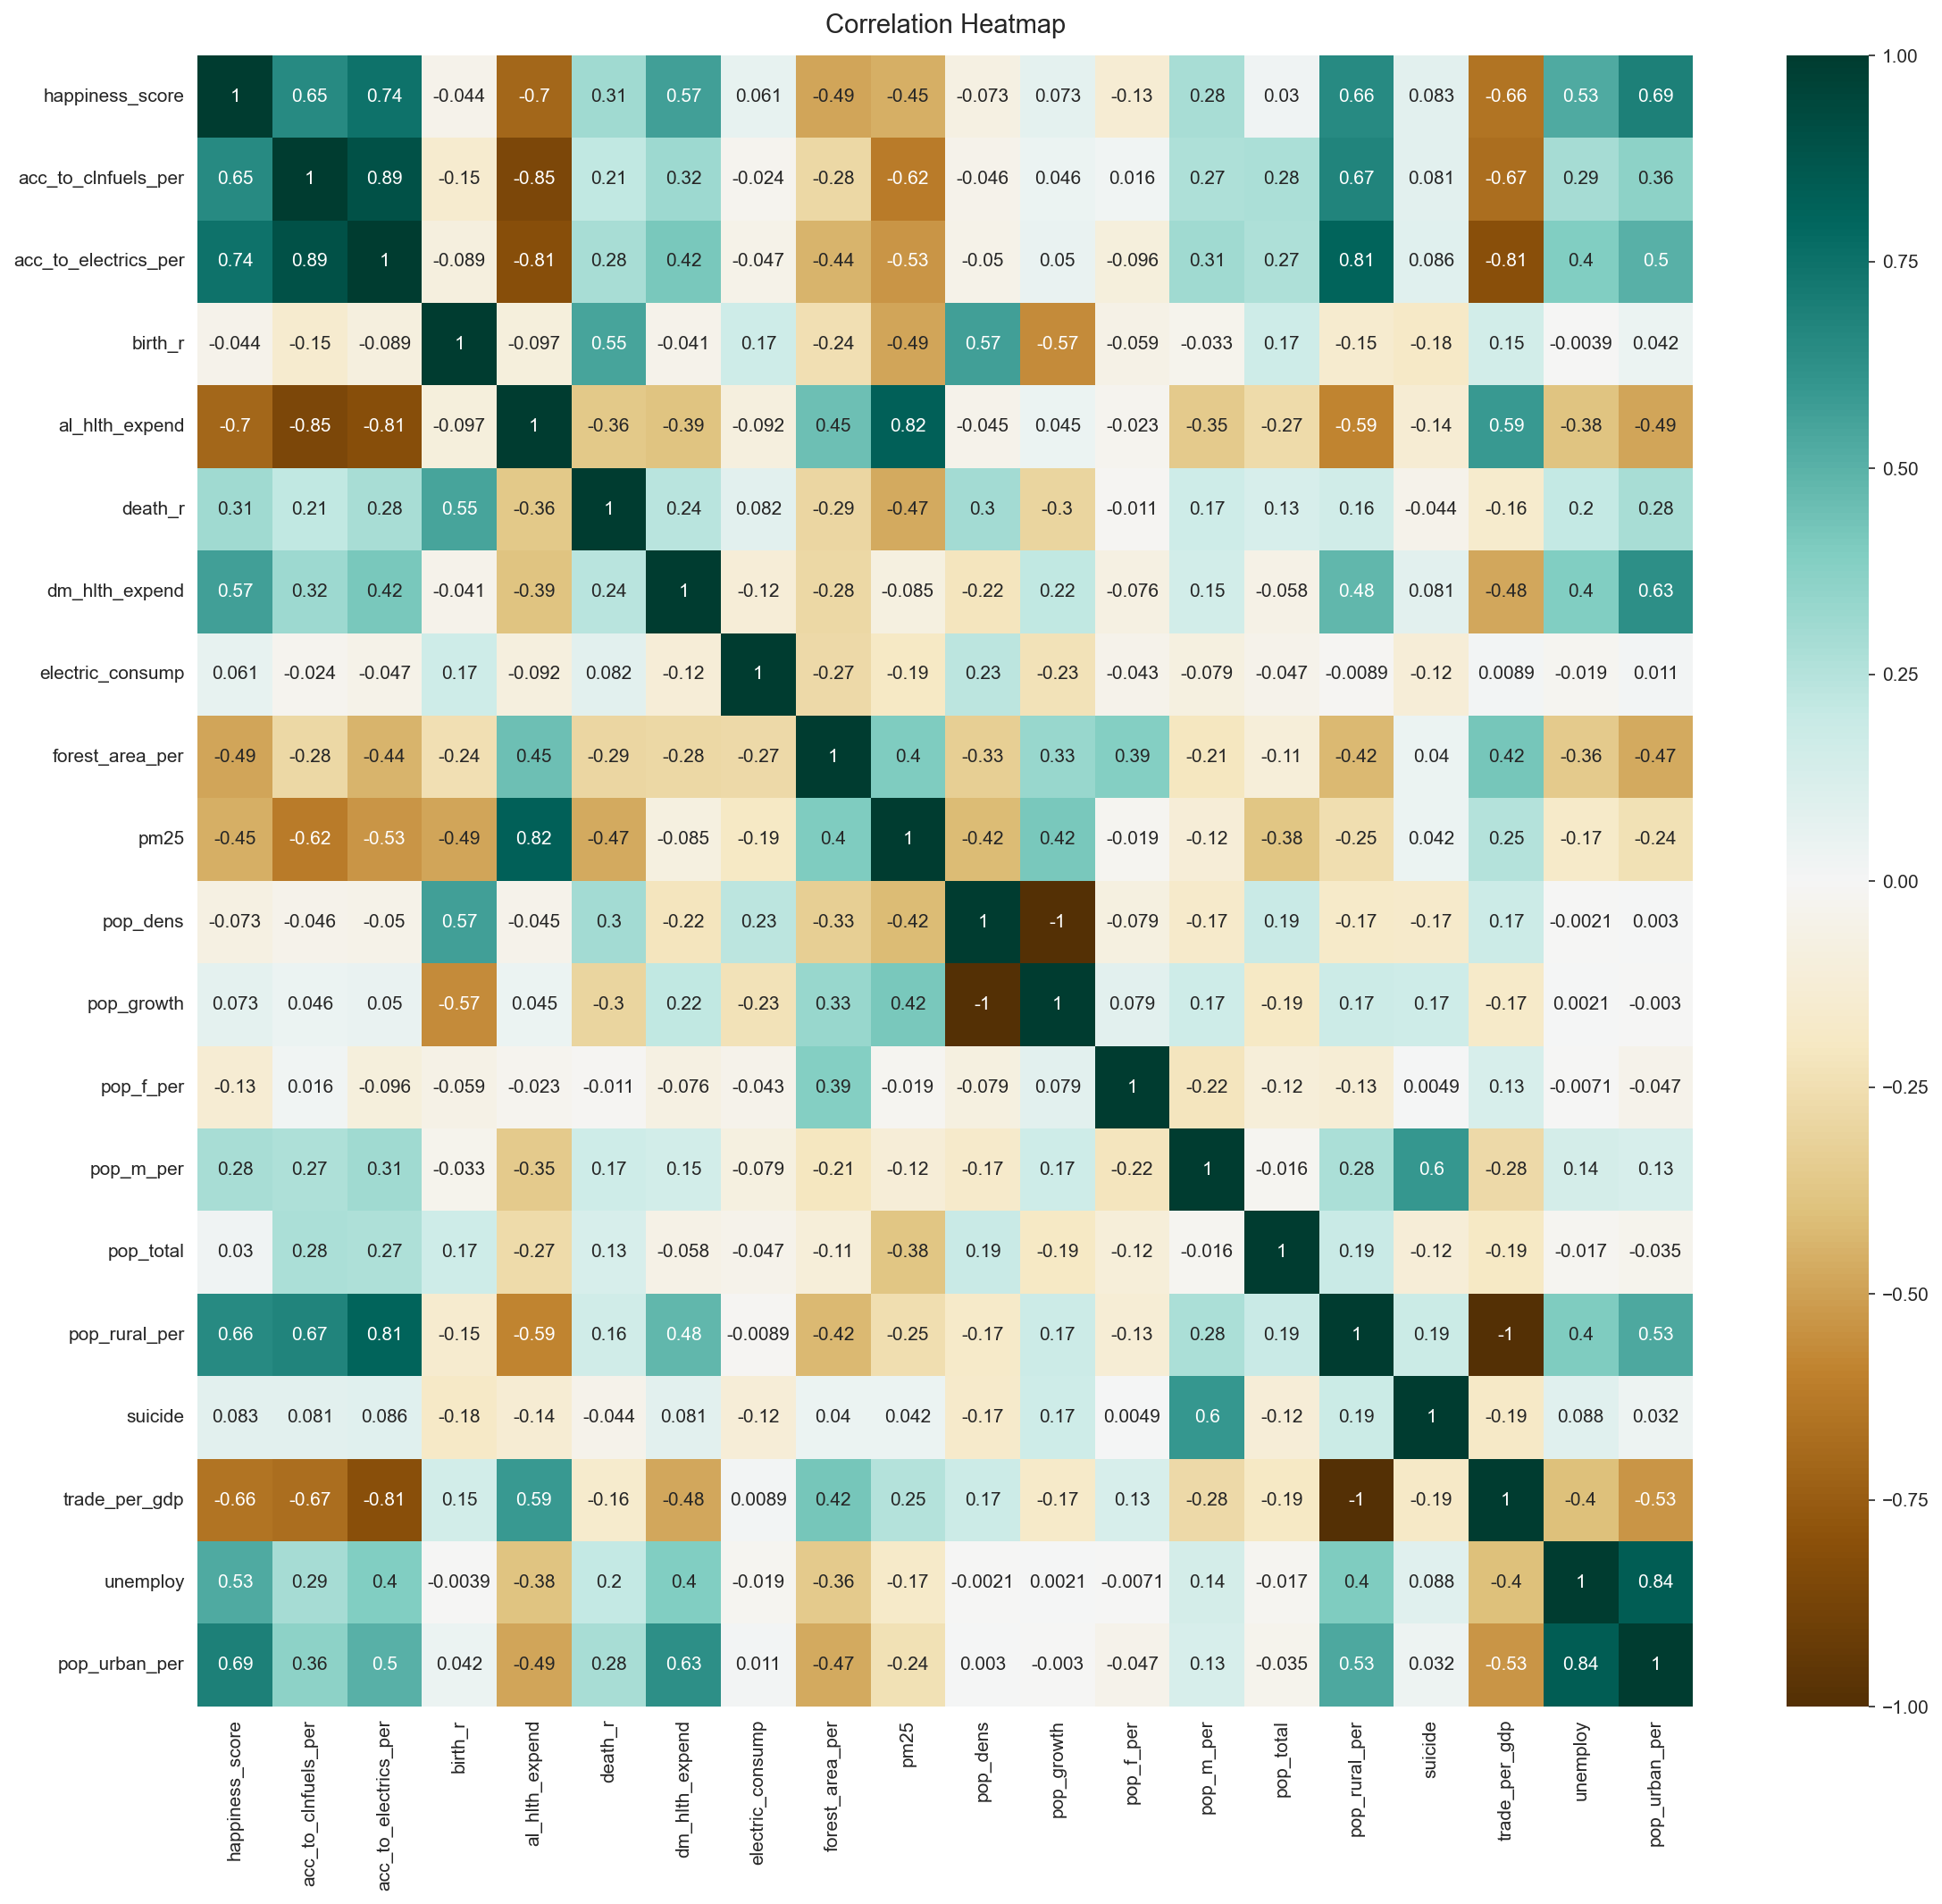

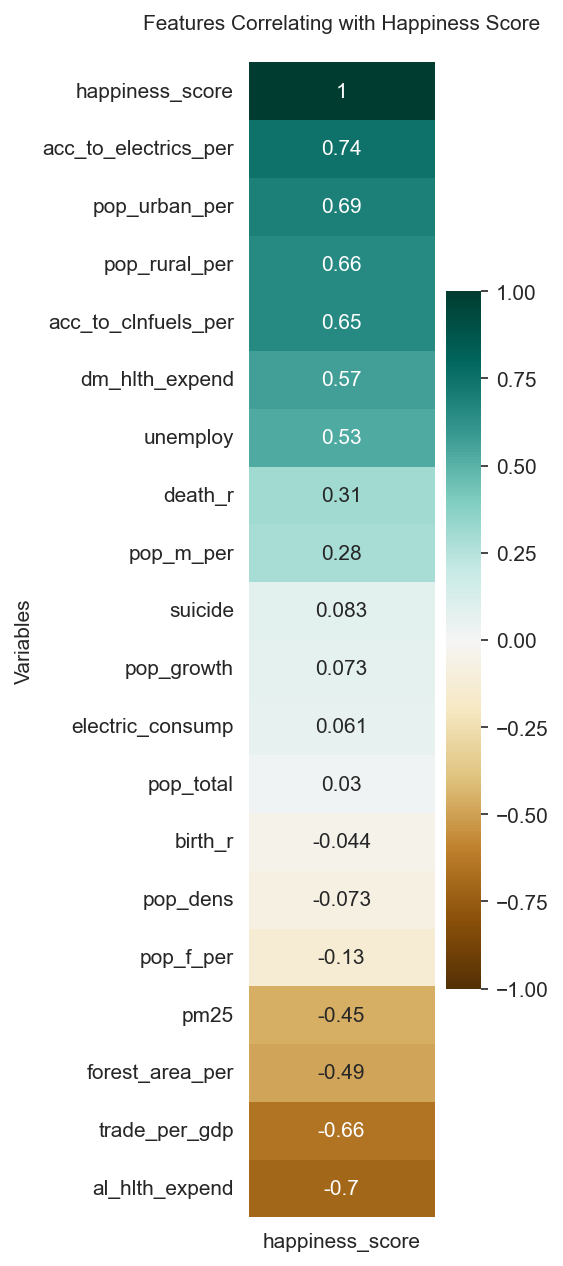

In [22]:
# Prepare new DATA

newdf_ol_mean = newdf_ol.groupby('country_name').apply(lambda x : x[['life_lad','gdp_per_cap','social_sup',
    'health','life_choice','generosity','corruption','pos_aff','neg_aff','conf_in_gov','acc_to_clnfuels_per',
    'acc_to_electrics_per','birth_r','al_hlth_expend','death_r','dm_hlth_expend','electric_consump','forest_area_per',
    'pm25','pop_dens','pop_growth','pop_f_per','pop_m_per','pop_total','pop_rural_per','suicide','trade_per_gdp',
    'unemploy','pop_urban_per' ]].mean()).sort_values(by=['life_lad'],ascending=False).reset_index()

newdf_ol_mean = pd.merge(df_w_overall[['Country','happiness_score']],newdf_ol_mean,left_on='Country',right_on='country_name',how='left').rename(columns={'Country':'country'}).drop(columns=['country_name'])

display(newdf_ol_mean)

# Plot

select = [ 'happiness_score','acc_to_clnfuels_per','acc_to_electrics_per','birth_r','al_hlth_expend','death_r','dm_hlth_expend',
    'electric_consump','forest_area_per','pm25','pop_dens','pop_growth','pop_f_per','pop_m_per','pop_total',
    'pop_rural_per','suicide','trade_per_gdp','unemploy','pop_urban_per']

newdf_ol_mean = newdf_ol_mean.loc[ :,select ]

# heatmap
plt.figure(figsize=(18, 16), dpi=150 )

heatmap = sns.heatmap(newdf_ol_mean.corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG' )
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)

# heatmap separated
plt.figure(figsize=(2, 10), dpi=150 )
heatmap = sns.heatmap(newdf_ol_mean.corr()[['happiness_score']].sort_values(by='happiness_score', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG' )
heatmap.set_title('Features Correlating with Happiness Score', fontdict={'fontsize':10}, pad=16)
heatmap.set( ylabel='Variables')


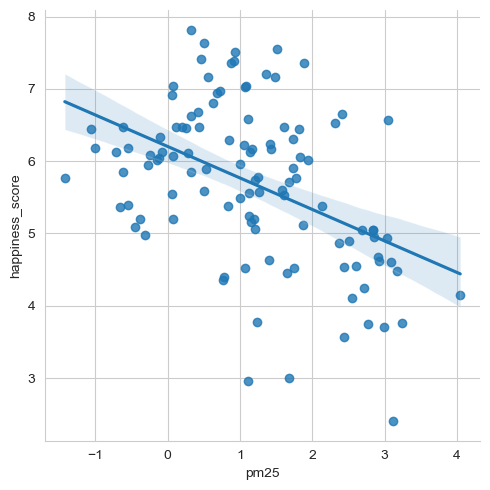

In [23]:
sns.lmplot( x="pm25", y="happiness_score", hue=None , data=newdf_ol_mean )